In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../notebooks/DATA/Salary Data.csv')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


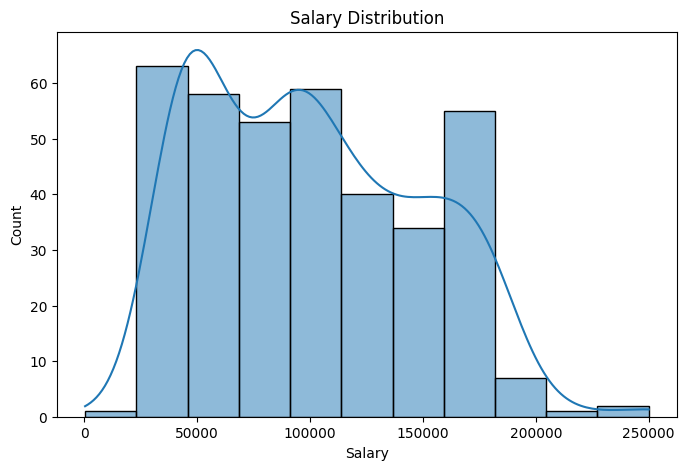

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

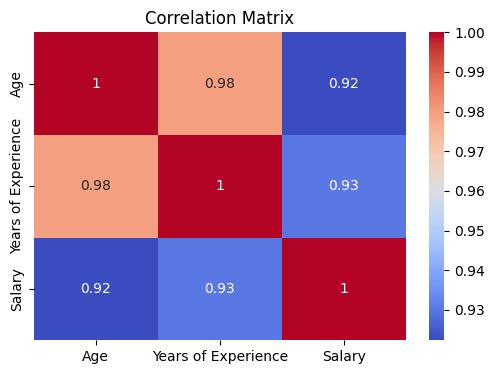

In [8]:
numeric_features = ["Age", "Years of Experience"]
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_features + ["Salary"]].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

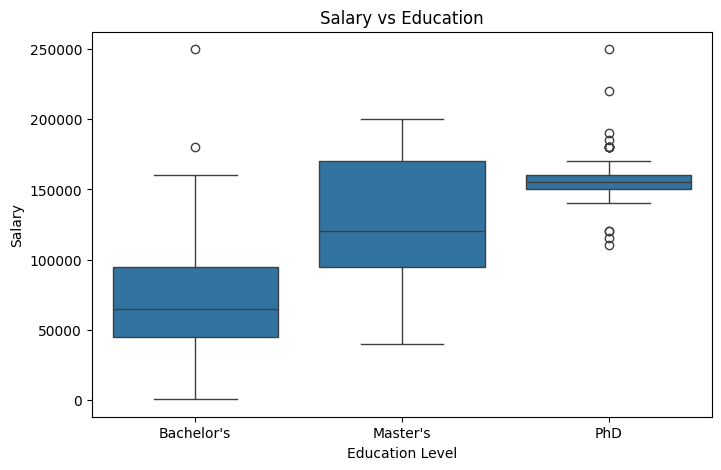

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education Level", y="Salary", data=df)
plt.title("Salary vs Education")
plt.show()

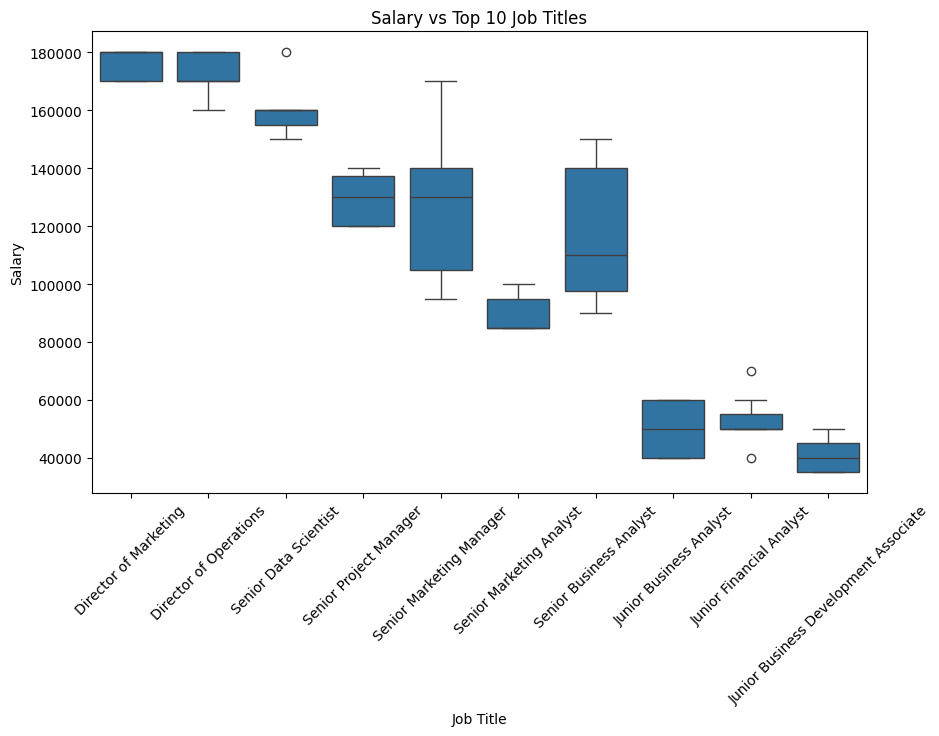

In [10]:
top_jobs = df["Job Title"].value_counts().head(10).index
plt.figure(figsize=(10,6))
sns.boxplot(x="Job Title", y="Salary", data=df[df["Job Title"].isin(top_jobs)])
plt.xticks(rotation=45)
plt.title("Salary vs Top 10 Job Titles")
plt.show()

In [19]:
df = df.dropna(subset=["Salary"])

In [20]:
target = "Salary"
X = df.drop(columns=[target])
y = df[target]

In [21]:
categorical_features = ["Job Title", "Education Level"]
for col in categorical_features:
    X[col] = X[col].fillna("Unknown")
for col in numeric_features:
    X[col] = X[col].fillna(X[col].median())

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [24]:
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}


In [26]:
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    
results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df.sort_values(by="R2", ascending=False))

Model Comparison:
                            MAE          RMSE        R2
Random Forest      10138.000000  17511.208315  0.872103
XGBoost            10459.307396  17569.844197  0.871246
Gradient Boosting  10897.061471  18203.242803  0.861795
Linear Regression  11675.283655  18915.171410  0.850773


In [27]:
best_model_name = results_df['R2'].idxmax()
print(f"Best model: {best_model_name}")

best_model = models[best_model_name]
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])
final_pipeline.fit(X_train, y_train)

Best model: Random Forest


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    importances = final_pipeline.named_steps["model"].feature_importances_
    feature_names = numeric_features + list(
        final_pipeline.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(categorical_features)
    )
    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)
    print("Top features influencing salary:")
    print(feature_importance_df.head(10))

Top features influencing salary:
                                feature  importance
0                                   Age    0.582378
1                   Years of Experience    0.322232
151          Education Level_Bachelor's    0.022797
8    Job Title_Chief Technology Officer    0.007035
3    Job Title_Administrative Assistant    0.005866
7          Job Title_Chief Data Officer    0.004988
153                 Education Level_PhD    0.004284
152            Education Level_Master's    0.003140
86                  Job Title_Recruiter    0.002777
126    Job Title_Senior Project Manager    0.002720


In [31]:
sample = pd.DataFrame({
    "Age": [30],
    "Years of Experience": [5],
    "Job Title": ["Data Scientist"],
    "Education Level": ["Bachelor"]
})

predicted_salary = final_pipeline.predict(sample)[0]
print(f"Predicted salary for sample: {predicted_salary:.2f}")

Predicted salary for sample: 59600.00
